# Engenharia de Características para a Aprendizagem Computacional
## Trabalho Prático 1
Trabalho realizado por:
- 
- 
- 

### Dataset
O Dataset utilizado é o FORTH-TRACE benchmark. O mesmo contém dados recolhidos de 5 sensores, incluindo sensores de aceleração, velocidade angular e variação do campo magnético, quer da parte superior, quer da parte inferior, do corpo.

### Bibliotecas Utilizadas

In [1]:
import numpy as np
import csv
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

### Exercício 2
#### 1. Carregamento dos dados
Os dados foram carregados a partir dos ficheiros CSV disponibilizados no dataset. À medida que os dados foram sendo adicionados a um array auxiliar, foi também adicionada uma coluna com o ID do participante, de forma a manter essa informação para os passos seguintes.

In [2]:
def load_data():
    dataset_root='../FORTH_TRACE_DATASET'
    data_rows = []
    for part_id in range(15):
        dataset_path = f"{dataset_root}/part{part_id}"
        participant_id = part_id
        for dev_id in range(1, 6):
            csv_file = f"{dataset_path}/part{part_id}dev{dev_id}.csv"
            with open(csv_file, 'r', newline='') as f:
                reader = csv.reader(f, delimiter=',')
                for row in reader:
                    arr = np.array(row, dtype=float)
                    # add participant ID
                    new_row = np.hstack((np.array([participant_id], dtype=float), arr))
                    data_rows.append(new_row)

    data = np.vstack(data_rows)

    return data


#fiz isto só p ver como estavam os dados
data= load_data()
print(data[:5])  


KeyboardInterrupt: 

### Exercício 3
Análise e tratamento de outliers: o objetivo será identificar e tratar outliers usando diferentes abordagens univariável e multivariável. Para o efeito iremos utilizar os módulos dos vectores aceleração, giroscópio e magnetómetro. Seja
$$ \vec{t} = (tx, ty, tz) $$
o vector aceleração, giroscópio e magnetómetro. O respetivo módulo é determinado recorrendo:
$$ ||\vec{t}|| = \sqrt{tx^2 + ty^2 + tz^2} $$

### Exercício 3.1
Elabore uma rotina que apresente simultaneamente o boxplot de cada atividade (coluna 12 – eixo horizontal) relativo a todos os sujeitos e a uma das seguintes variáveis transformadas: módulos dos vectores de aceleração, giroscópio e magnetómetro. Sugere-se o uso da biblioteca matplotlib, por exemplo, a classe matplotlib.pyplot.boxplot.

In [ ]:
def module_boxplots(data, sensor):
    #acel
    if sensor == 1:
        c = (2,3,4)
        label = 'Aceleration'
    # giro
    elif sensor == 2:
        c = (5,6,7)
        label = 'Gyroscope'
    #magn
    elif sensor == 3:
        c = (8,9,10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 0, 1, or 2")
    # compute module by line (sqrt(x^2 + y^2 + z^2))
    mod = np.sqrt((data[:,c]**2).sum(axis=1))
    
    participant = data[:, 0].astype(int)
    device = data[:, 1]
    activities = data[:,12]
    
    unique_activities = np.unique(activities).astype(int)
    unique_devices= np.unique(device).astype(int)
    
    boxplot_data = []
    labels = []
    for act in unique_activities:
        for dev in unique_devices:
            mask = (activities == act) & (device == dev)
            mods_from_act = mod[mask]
            boxplot_data.append(mods_from_act)
            labels.append(f"A{act}-D{dev}")
        
    '''tp1.ipynbplt.figure(figsize=(12,6))
    plt.boxplot(boxplot_data, tick_labels=unique_activities)
    plt.xlabel('Activity')
    plt.ylabel(f'Module {label}')
    plt.title(f'Boxplot of {label} Module by Activity and device')
    plt.show()'''
    
    plt.figure(figsize=(16, 6))
    plt.boxplot(boxplot_data, labels=labels, showfliers=False)
    plt.xticks(rotation=90)
    plt.xlabel('Activity - Device')
    plt.ylabel(f'{label} Module')
    plt.title(f'Boxplot of {label} Module by Activity and Device')
    plt.tight_layout()
    plt.show()

    


/tmp/ipykernel_15311/442924624.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


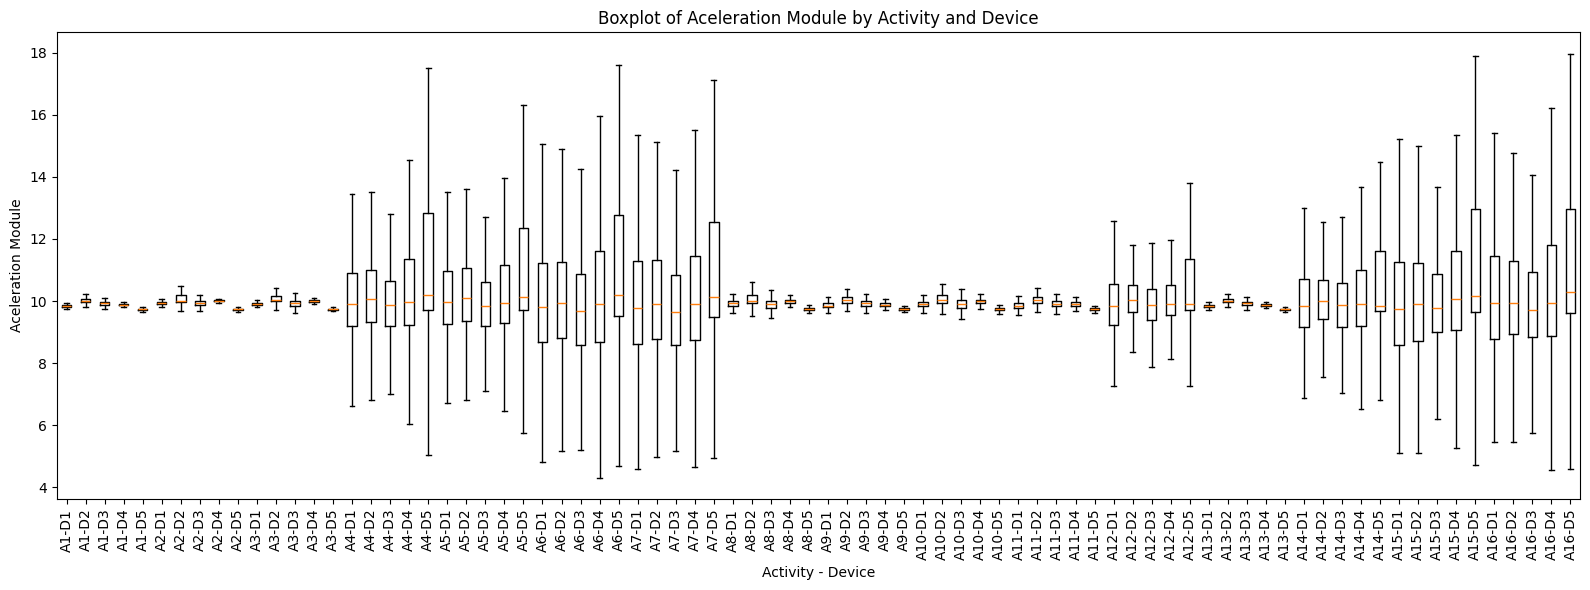

/tmp/ipykernel_15311/442924624.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


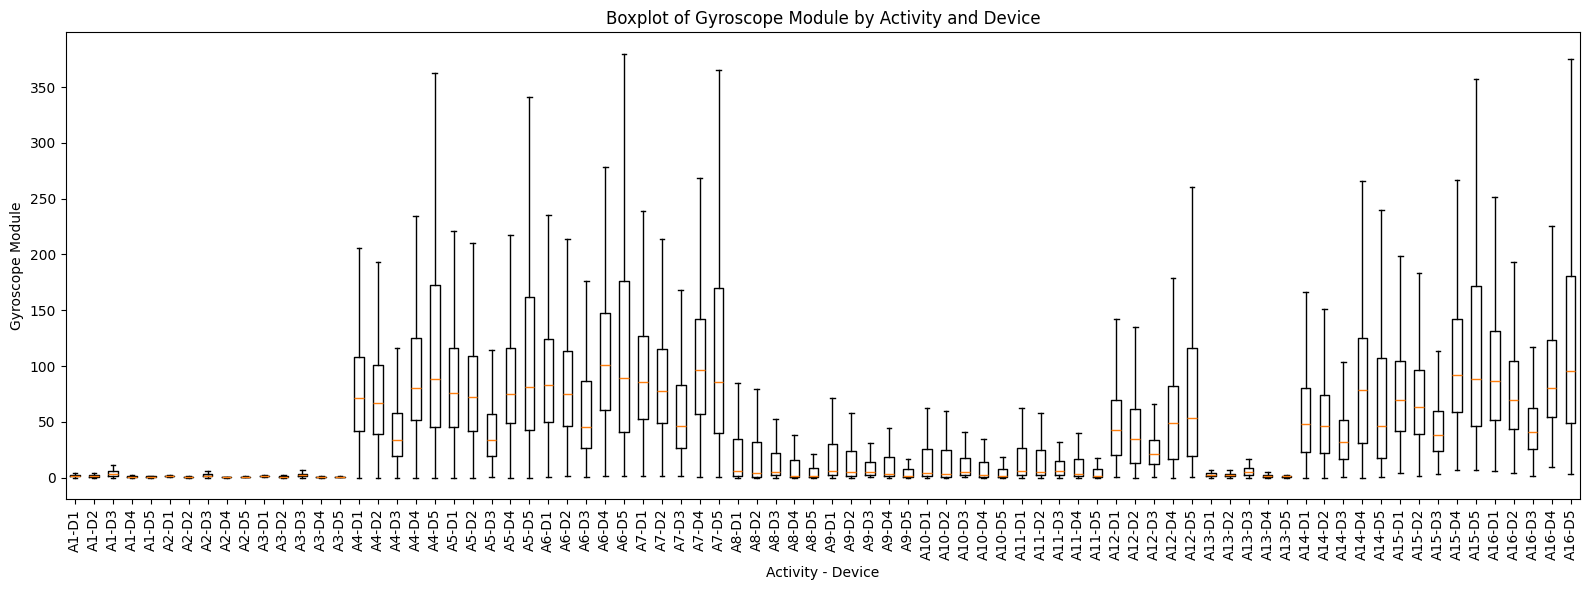

/tmp/ipykernel_15311/442924624.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


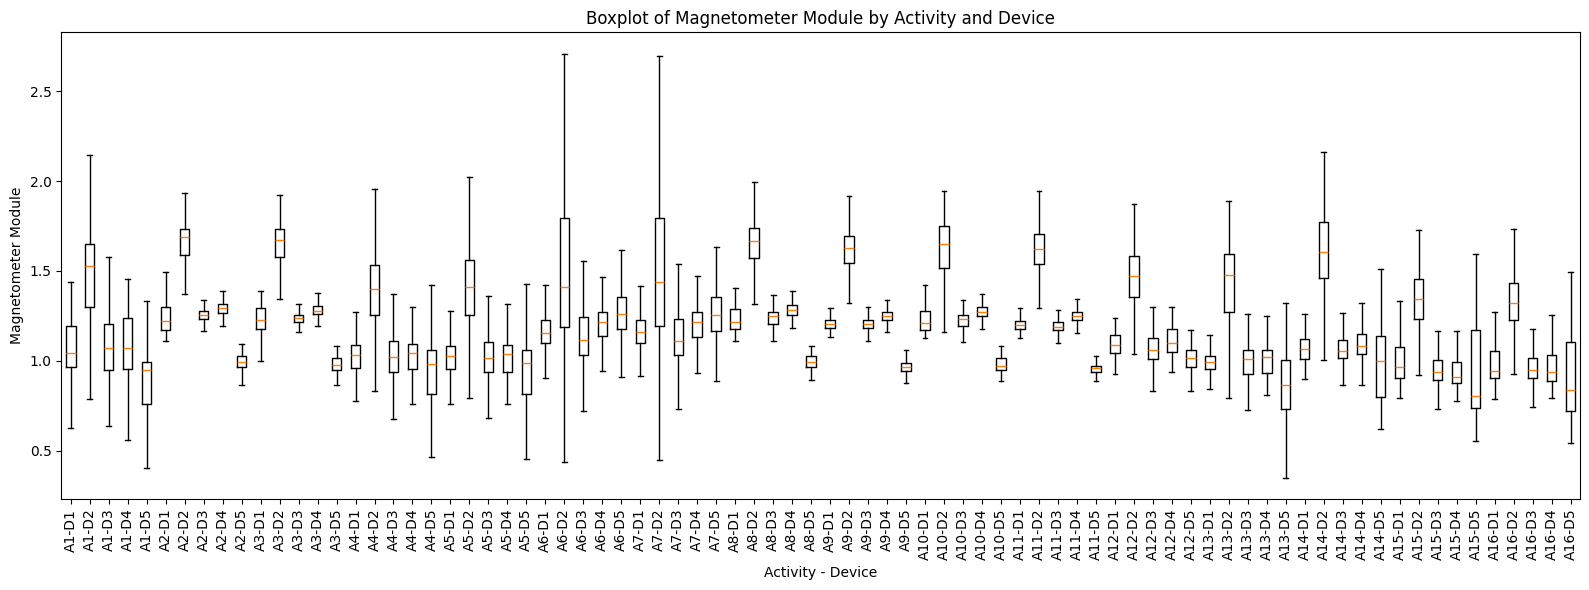

In [ ]:
module_boxplots(data, 1)
module_boxplots(data, 2)
module_boxplots(data, 3)

  ## Observações:- TEMOS AGORA DE ADAPTAR ISTO
  ### Geral:
  Existe uma grande presença de outliers em todos os sensores, o que é visível em praticamente todas as atividades. Sugere que os movimentos humanos contêm variações extremas? É necessário aprofundar a análise para perceber se estes outliers são de facto variações extremas ou se são erros de medição.
  ### Aceleração:
  #### Módulo Aceleração:
  - As atividades estáticas (1, 2, 3) apresentam uma mediana próxima de 10, que correspondem, aproximadamente, à aceleração da gravidade (~9.81 m/s²), com uma variabilidade muito reduzida(caixas pequenas). Isto indica que o corpo está maioritariamente em repouso.
  - As atividades dinâmicas (4,5,6,7) apresentam maior dispersão. Isto reflete a constante variação de aceleração inerente a estas atividades.
  #### Conclusão:
  - Os resultados são os esperados. O módulo da aceleração parece ser uma característica útil para distinguir entre atividades estáticas e dinâmicas.
  ### Giroscópio:
  #### Módulo Giroscópio:
  - Nas atividades estáticas, a mediana está praticamente a zero e a caixa é quase inexistente, indicando pouca ou nenhuma rotação. Sem movimento, não existe velocidade angular.
  - Nas atividades dinâmicas os valores de módulo e a dispersão são significativamente maiores, com outliers evidentes.
  #### Conclusão:
  - O giroscópio apresenta a distanção mais clara entre os dois tipos de atividade.
  ### Magnetómetro:
  #### Módulo Magnetómetro:
  - Existe uma enorme quantidade de outliers nas atividades 6 (Climb Stair) e 7 (Climb Stair and talk). Esse fenómeno provavelmente não se deve ao movimento em si, mas sim ao facto de escadas conterem frequentemente estruturas metálicas (corrimões, vigas, etc.) que podem interferir com o sensor magnético.
  - As atividades estáticas apresentam uma mediana
  #### Conclusão:
  - Ao contrário dos outros sensores, o magnetómetro não mostra uma distinção tão óbvia entre a maioria das atividades estáticas e dinâmicas. As medianas e os intervalos interquartis são relativamente semelhantes entre muitas das atividades. Mas em contrapartida, o magnetómetro pode ser um indicador de uma atividade relacionada com escadas, devido à quantidade de outliers observados.

### Exercício 3.2
Analise e comente a densidade de outliers existentes no dataset transformado, isto é, nos módulos dos vetores aceleração, giroscópio e magnetómetro para cada atividade (use somente os sensores do pulso direito). Observe que a densidade é determinada recorrendo:
$$ d = \frac{no}{nr} * 100 $$
em que no é o número de pontos classificados como outliers e nr é o número total de pontos.

In [ ]:
def outliers_density(data, sensor):
    #Only remove data from device id 2
    # dr = (number of outliers / total number of samples) * 100
    device_id = 2
    device_data = data[data[:,1] == device_id]
    #total_num_samples = device_data.shape[0]
    
    #acel
    if sensor == 1:
        c = (2,3,4)
        label = 'Aceleration'
    # giro
    elif sensor == 2:
        c = (5,6,7)
        label = 'Gyroscope'
    #magn
    elif sensor == 3:
        c = (8,9,10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 0, 1, or 2")
    # UTILIZAR TUKEY RULE PARA DETEÇÃO DE OUTLIERS (OU SEJA, VERIFICAR SE ESTÃO FORA DOS LIMITES)
    
    
    sensor_data= device_data[:, c]
    magnitude= np.linalg.norm(sensor_data, axis=1)
    
    activities= device_data[:,12]
    unique= np.unique(activities)
    results= {}
    outlier_counts=[]
    
    for a in unique: 
        mag = magnitude[activities==a]
    
        
        Q1= np.percentile (mag, 25)
        Q3= np.percentile (mag, 75)
        IQR= Q3-Q1
        lower_limit= Q1-1.5*IQR
        upper_limit= Q3+1.5*IQR
        
        outliers = (mag < lower_limit) | (mag > upper_limit)
        
        nr= len(mag)
        no= np.sum(outliers)
        
        if nr > 0:
            density = (no / nr) * 100
        else:
            density = 0
        
        results[a] = {
            'density': density,
            'total_points': nr,
            'outliers_count': no
        }
        outlier_counts.append(no)
        
        
    plt.figure(figsize=(10,5))
    plt.bar(unique, outlier_counts)
    plt.ylabel('Number of Outliers')
    plt.title(f'Number of Outliers – {label} (Device 2)')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()
    
    #return results, label

    

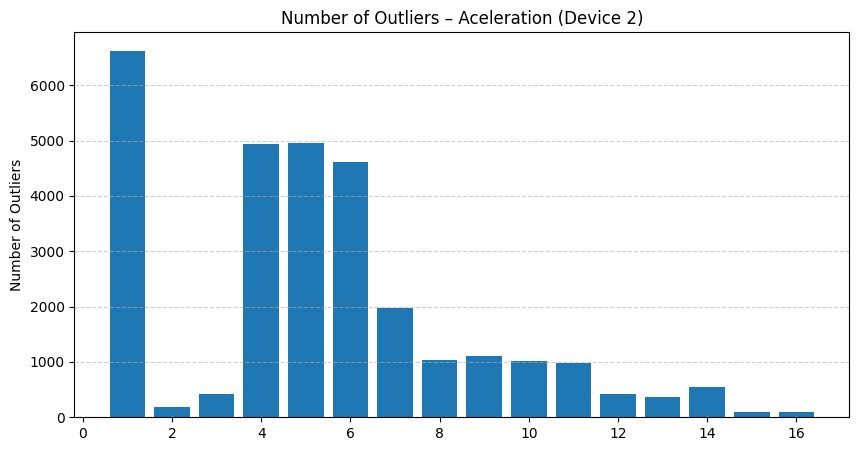

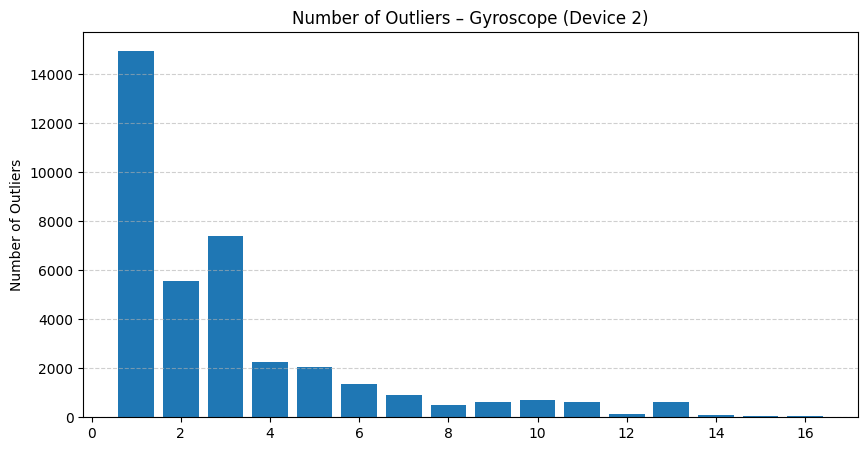

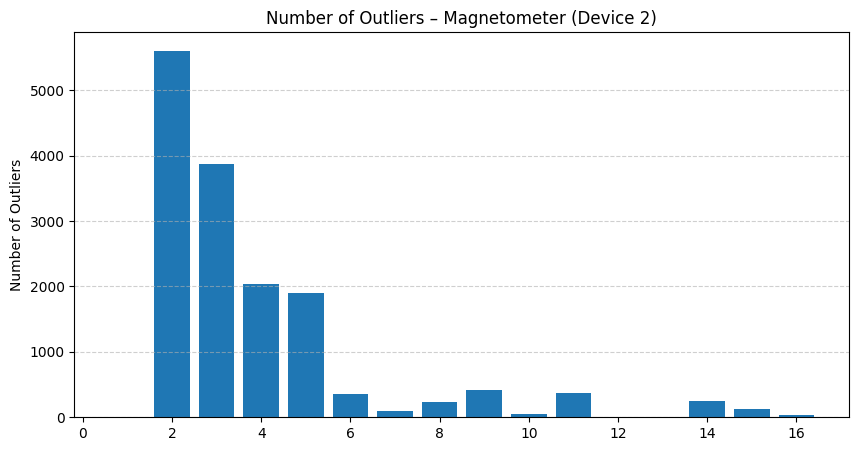

In [ ]:
outliers_density(data, 1)
outliers_density(data, 2)
outliers_density(data, 3)

#### Acho que era interessante se tivessemos para além destes gráficos de barras uma tabela, por exemplo, com percentagens de outliers para cada atividade e sensor.

comentar depois, fazer uma observaçao. aqui nao sei mt bem se é p fazer por participante ou atividade, ou seja, nao sei se fiz os graficos be (nao sei s me fiz entender)

### Exercício 3.3
Escreva uma rotina que receba um Array de amostras de uma variável e identifique os outliers usando o teste Z-Score para um k variável (parâmetro de entrada).

In [ ]:
def detect_outliers_zscore (samples, k):
    mean= np.mean(samples)
    std= np.std(samples)
    
    z_scores = np.abs((samples - mean) / std)
    
    outliers= z_scores>k
    
    return outliers
    
#exemplo
acc_sample= np.sqrt(data[:, 2]**2 + data[:, 3]**2 + data[:, 4]**2)
acc_outliers = detect_outliers_zscore(acc_sample, k=3)
print (acc_outliers) #quando sai true é outlier


[False False False ... False False False]


### Exercício 3.4
Usando o Z-score implementado, assinale todos as amostras consideradas outliers nos módulos dos vetores de aceleração, giroscópio e magnetómetro.
Apresente plots em que estes pontos surgem a vermelho, enquanto os restantes surgem a azul. Use k=3, 3.5 e 4.

In [ ]:
def plot_zscore_outliers (data, sensor, k_values=[3.0,3.5,4.0]):
    if sensor == 1:  
        c = (2, 3, 4)
        label = 'Acceleration'
    elif sensor == 2: 
        c = (5, 6, 7)
        label = 'Gyroscope'
    elif sensor == 3:  
        c = (8, 9, 10)
        label = 'Magnetometer'
        
    mod = np.sqrt((data[:,c]**2).sum(axis=1))
    all = data[:,12]
    unique_activities = np.unique(all).astype(int)
    
    
    for k in k_values:
        plt.figure(figsize=(8,5))
        plt.title(f'{label} - Outliers Z-Score (k={k})')
        
        for i, act in enumerate(unique_activities):
            mod_act = mod[all == act]
            out = detect_outliers_zscore(mod_act, k)
            
            # Pontos normais em azul
            normais = mod_act[out == False]  # pega apenas os que não são outliers
            plt.scatter([i+1]*len(normais), normais, color='blue', s=20)

            # Outliers em vermelho
            outliers = mod_act[out == True]  # ou simplesmente mod_act[out]
            plt.scatter([i+1]*len(outliers), outliers, color='red', s=40)

        plt.xlabel('Atividade')
        plt.ylabel('Módulo')
        plt.xticks(range(1, len(unique_activities)+1), unique_activities)
        plt.show()

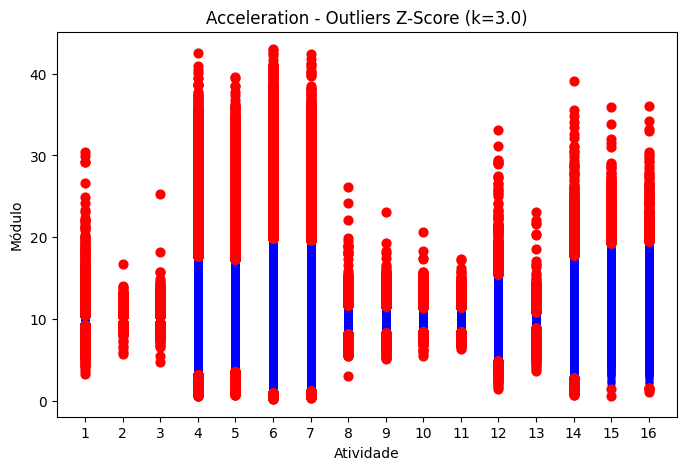

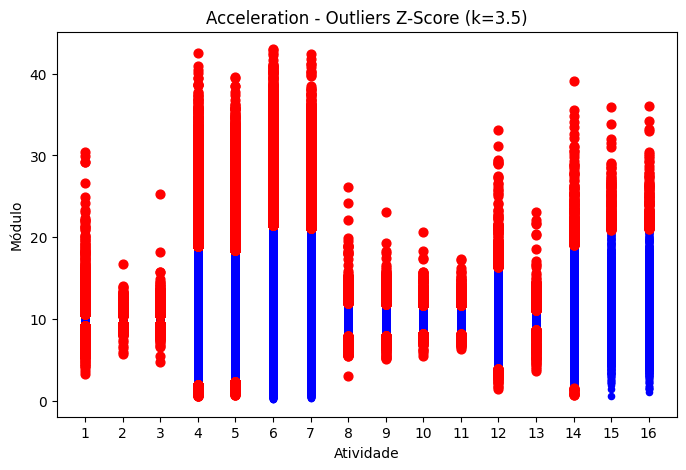

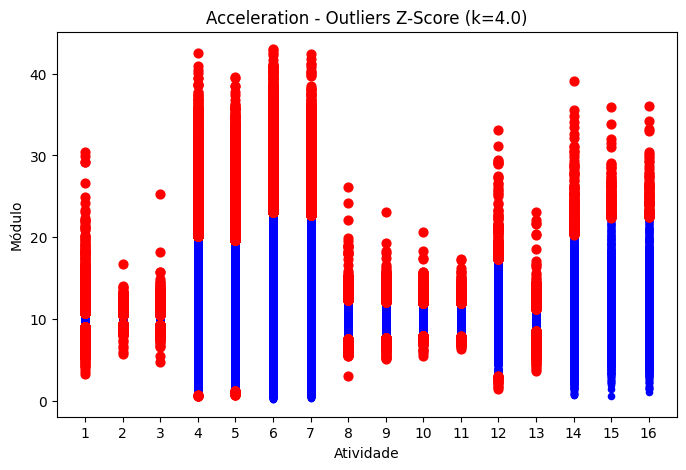

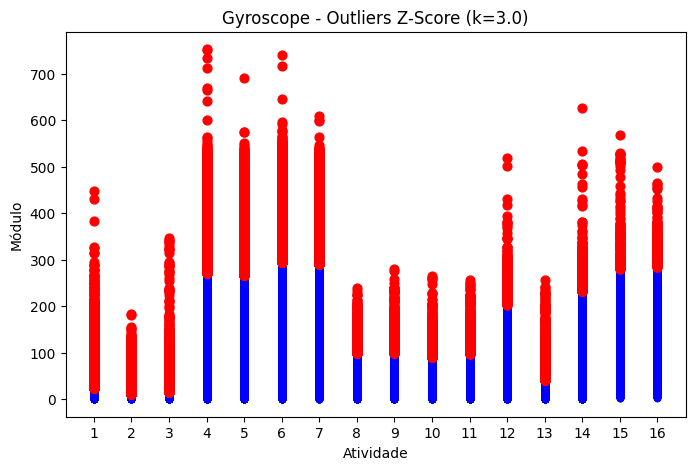

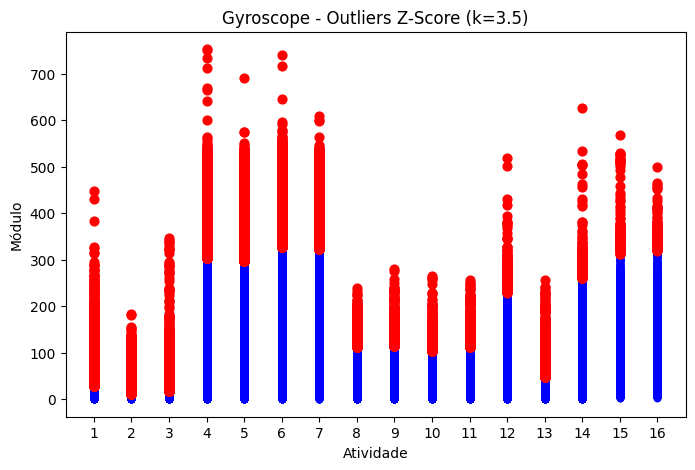

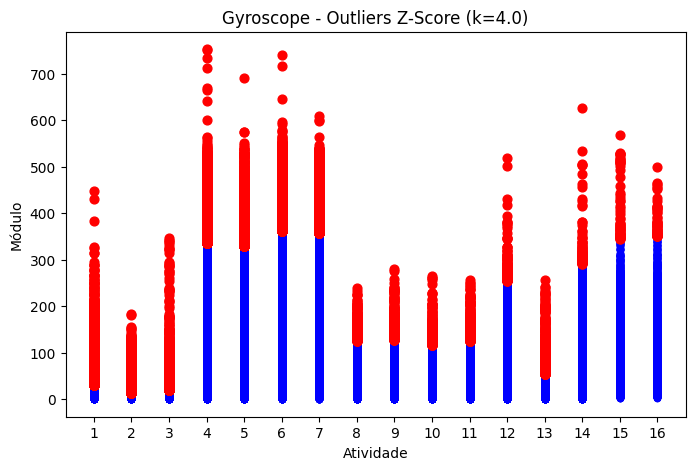

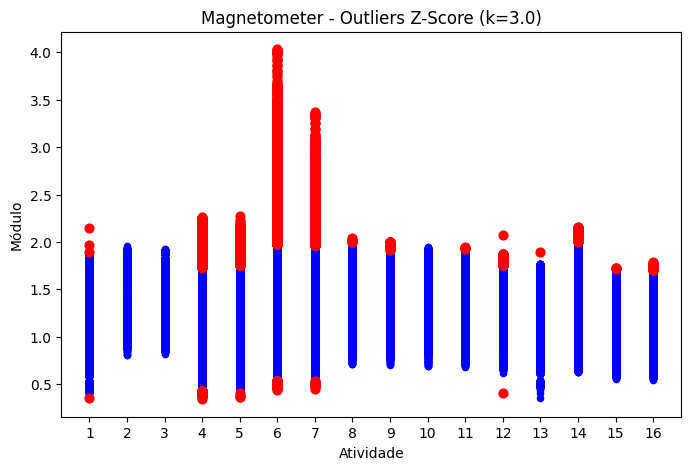

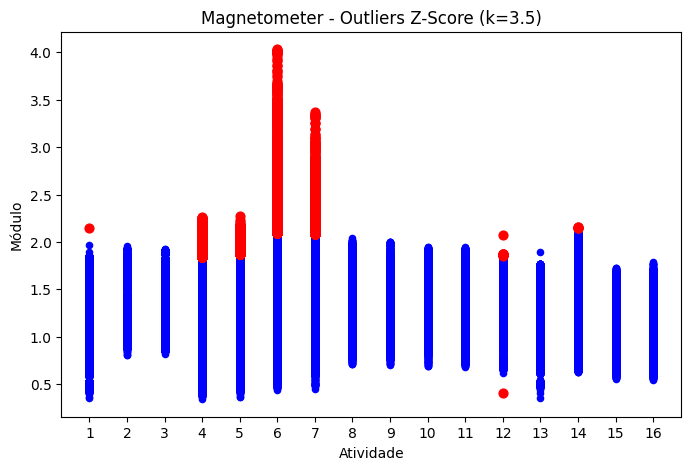

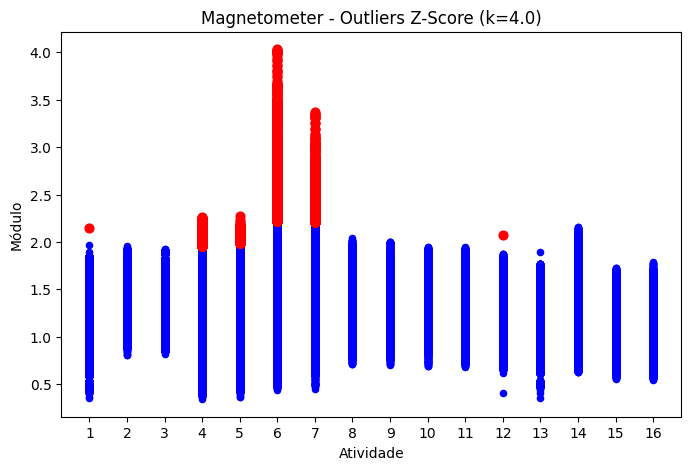

In [ ]:
plot_zscore_outliers(data, sensor=1)  # Aceleração
plot_zscore_outliers(data, sensor=2)  # Giroscópio
plot_zscore_outliers(data, sensor=3)  # Magnetômetro

### Exercício 3.5
#### Compare e discuta os resultados obtidos em 3.1 e 3.4. (CONTINUAR)

Quando o k aumenta menos filtra os outliers

### Exercício 3.6
Elabore uma rotina que implemente o algoritmo k-means para n (valor de entrada) clusters.

In [ ]:
def kmeans (data, n_clusters, max_iter=100, tol=1e-4):
    centroids= data[np.random.choice(data.shape[0], n_clusters, replace=False)]
    
    for i in range(max_iter):
        labels = np.zeros(data.shape[0], dtype=int)
        
        # Passo 1: atribui cada ponto ao cluster mais próximo
        for i, point in enumerate(data):
            min_dist = float('inf')
            for k in range(n_clusters):
                dist = np.linalg.norm(point - centroids[k])
                if dist < min_dist:
                    min_dist = dist
                    labels[i] = k
                    
        # Passo 2: atualiza centróides
        new_centroids = np.zeros_like(centroids)
        for k in range(n_clusters):
            cluster_points = data[labels == k]
            if len(cluster_points) > 0:
                new_centroids[k] = cluster_points.mean(axis=0)
            else:
                # Se algum cluster ficar vazio, reposiciona aleatoriamente
                new_centroids[k] = data[np.random.choice(data.shape[0])]
        
        if np.all(np.linalg.norm(new_centroids - centroids, axis=1) < tol):
            break
        
        centroids = new_centroids
    
    return labels, centroids
            

## Exercício 3.7

Determine os outliers no dataset transformado usando o k-means. Experimente diferentes números de clusters e compare com os resultados obtidos em 3.4. Ilustre graficamente os resultados usando gráficos 3D para cada vetor

In [ ]:
def kmeans_outliers (data, sensor, k_values, threshold=2.5):
    if sensor == 1:  
        c = (2, 3, 4)
        label = 'Acceleration'
    elif sensor == 2: 
        c = (5, 6, 7)
        label = 'Gyroscope'
    elif sensor == 3:  
        c = (8, 9, 10)
        label = 'Magnetometer'
        
    sensor_data = data[:, c]
    activities_all = data[:, 12]
    unique_activities = np.unique(activities_all).astype(int)

    # Loop K-Values
    for k_clusters in k_values:

        print(f'K-Means Outliers Detection - {label} (k={k_clusters})')

        for i, act in enumerate(unique_activities):
            print(f' Activity {act}')
            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')
            ax.set_title(f'{label} - K-Means Outliers (k={k_clusters})')
        
            activity_data = sensor_data[activities_all == act]    
            
            if activity_data.shape[0] == 0:
                plt.close(fig)
                continue

            labels, centroids = kmeans(activity_data, k_clusters)
            outliers_idx = []
            
            for cluster_id in range(k_clusters):
                cluster_points_idx = np.where(labels == cluster_id)[0]
                
                if(len(cluster_points_idx) == 0):
                    continue
                
                cluster_points = activity_data[cluster_points_idx]
                distances = np.linalg.norm(cluster_points - centroids[cluster_id], axis=1)
    
                Q1 = np.percentile(distances, 25)
                Q3 = np.percentile(distances, 75)
                IQR = Q3 - Q1
                upper_limit = Q3 + 1.5 * IQR

                outliers_idx.extend(cluster_points_idx[distances > upper_limit])
            
            all_idx = np.arange(len(activity_data))
            normal_mask = np.ones(len(activity_data), dtype=bool)
            normal_mask[outliers_idx] = False
            normal_idx = all_idx[normal_mask]

            # Pontos normais em azul
            ax.scatter(activity_data[normal_idx,0], activity_data[normal_idx,1], activity_data[normal_idx,2],
                       color='blue', s=20)

            # Outliers em vermelho
            ax.scatter(activity_data[outliers_idx,0], activity_data[outliers_idx,1], activity_data[outliers_idx,2],
                       color='red', s=40)
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_zlabel('Z')
            ax.legend()
            plt.show()

In [ ]:
# Run K-Means outlier detection
devices_to_use = [3, 4, 5]  # Example device IDs to include
k_values_to_use = [3, 5, 7]

for dev_id in devices_to_use:
    device_data = data[data[:, 1] == dev_id]
    print(f'Device ID: {dev_id}')
    kmeans_outliers(device_data, sensor=1, k_values=k_values_to_use)  # Acceleration
    kmeans_outliers(device_data, sensor=2, k_values=k_values_to_use)  # Gyroscope
    kmeans_outliers(device_data, sensor=3, k_values=k_values_to_use)  # Magnetometer

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7f4fb646aa70> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

### Exercício 3.7.1 (Bónus)
Poderá realizar um estudo análogo usando o algoritmo DBSCAN (sugere-se que recorra à [biblioteca sklearn2](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html#sklearn.cluster.DBSCAN))